In [14]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os
import glob
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.path import Path
import matplotlib.patches as patches

In [28]:
def load_imd_rainfall(year, imd_folder):
    """
    Load IMD daily rainfall NetCDF for a given year.
    Handles different file naming conventions and standardizes dimension names.

    Parameters
    ----------
    imd_folder : str
        Folder containing IMD NetCDF files. Files can be named either:
        - 'data_YYYY.nc' (for 2-degree resolution)
        - 'YYYY.nc' (for 4-degree resolution)
    year : int
        Year to load.

    Returns
    -------
    rainfall_ds : xarray.DataArray
        IMD rainfall data with standardized dims ['lat','lon','time'].
    """
    # Try different file naming conventions
    file_patterns = [f"data_{year}.nc", f"{year}.nc"]
    
    imd_file = None
    for pattern in file_patterns:
        test_path = f"{imd_folder}/{pattern}"
        if os.path.exists(test_path):
            imd_file = test_path
            break
    
    if imd_file is None:
        available_files = [f for f in os.listdir(imd_folder) if f.endswith('.nc')]
        raise FileNotFoundError(
            f"No IMD file found for year {year} in {imd_folder}. "
            f"Tried patterns: {file_patterns}. "
            f"Available files: {available_files}"
        )
    
    print(f"Loading IMD rainfall from: {imd_file}")
    
    ds = xr.open_dataset(imd_file)
    rainfall = ds['RAINFALL']
    
    # Standardize dimension names
    dim_mapping = {}
    
    # Check for latitude/longitude dimensions
    if 'latitude' in rainfall.dims:
        dim_mapping['latitude'] = 'lat'
    if 'LATITUDE' in rainfall.dims:
        dim_mapping['LATITUDE'] = 'lat'
    if 'longitude' in rainfall.dims:
        dim_mapping['longitude'] = 'lon'
    if 'LONGITUDE' in rainfall.dims:
        dim_mapping['LONGITUDE'] = 'lon'
    if 'TIME' in rainfall.dims:
        dim_mapping['TIME'] = 'time'
    
    # Apply renaming if any mappings found
    if dim_mapping:
        rainfall = rainfall.rename(dim_mapping)
    return rainfall

In [3]:
#### functions to detect observed onset dates ####
def detect_observed_onset(rainfall_ds, thresh_slice, year, mok=True):
    """
    Detect observed onset dates for a given year.
    
    Parameters:
    rainfall_ds: xarray DataArray with rainfall data
    thresh_slice: xarray DataArray with threshold values
    year: int, year to process
    mok: bool, if True use June 2nd as start date (MOK), if False use May 1st
    
    Returns:
    onset_da: xarray DataArray with onset dates
    """
    # Subset rainfall data
    rain_slice = rainfall_ds
    
    # Parameters
    window = 5
    
    # Set start date based on mok flag
    if mok:
        start_date = datetime(year, 6, 2)  # MOK date: June 2nd
        date_label = "MOK date (June 2nd)"
    else:
        start_date = datetime(year, 5, 1)  # May 1st
        date_label = "May 1st"

    # Find start date index
    time_dates = pd.to_datetime(rain_slice.time.values)
    start_idx_candidates = np.where(time_dates > start_date)[0]
    
    if len(start_idx_candidates) == 0:
        print(f"Warning: {date_label} ({start_date.strftime('%Y-%m-%d')}) not found in data for year {year}")
        # Fallback to April 1st if start date not available
        fallback_date = datetime(year, 4, 1)
        start_idx = np.where(time_dates >= fallback_date)[0][0]
        print(f"Using fallback date: April 1st")
    else:
        start_idx = start_idx_candidates[0]
        print(f"Using {date_label} ({start_date.strftime('%Y-%m-%d')}) as start date for onset detection")

    # Subset rain_slice from start date onward
    rain_subset = rain_slice.isel(time=slice(start_idx, None))

    # Create rolling 5-day sums
    rolling_sum = rain_subset.rolling(time=window, min_periods=window, center=False).sum()
    rolling_sum_aligned = rolling_sum.shift(time=-(window-1))

    # Create onset condition
    first_day_condition = rain_subset > 1
    sum_condition = rolling_sum_aligned > thresh_slice
    onset_condition = first_day_condition & sum_condition

    # Find first occurrence of onset condition for each grid point
    def find_first_true(arr):
        if arr.any():
            return int(np.argmax(arr))
        else:
            return -1

    onset_indices = xr.apply_ufunc(
        find_first_true,
        onset_condition,
        input_core_dims=[['time']],
        output_dtypes=[int],
        vectorize=True
    )

    # Convert indices to actual dates
    valid_mask = onset_indices.values >= 0
    time_coords = rain_subset.time.values
    onset_dates_array = np.full(onset_indices.shape, np.datetime64('NaT'), dtype='datetime64[ns]')

    for i in range(onset_indices.shape[0]):
        for j in range(onset_indices.shape[1]):
            if valid_mask[i, j]:
                idx = int(onset_indices[i, j].values)
                if 0 <= idx < len(time_coords):
                    onset_dates_array[i, j] = time_coords[idx]

    # Create final onset date DataArray
    onset_da = xr.DataArray(
        onset_dates_array,
        coords=[('lat', rain_slice.lat.values), ('lon', rain_slice.lon.values)],
        name='onset_date'
    )
    
    return onset_da

In [21]:
def compute_climatological_onset(imd_folder, thres_file, mok=True):
    """
    Compute climatological onset dates from all available IMD files.
    
    Parameters:
    imd_folder: str, folder containing IMD NetCDF files
    thres_file: str, path to threshold file
    mok: bool, if True use June 2nd as start date (MOK), if False use May 1st
    
    Returns:
    climatological_onset_doy: xarray DataArray with climatological onset day of year
    """
    
    # Load threshold data
    thresh_ds = xr.open_dataset(thres_file)
    thres_da = thresh_ds['MWmean']
    
    # Find all IMD files and extract years
    imd_files = glob.glob(os.path.join(imd_folder, "*.nc"))
    years = []
    
    for file_path in imd_files:
        filename = os.path.basename(file_path)
        # Remove .nc extension
        name_without_ext = filename.replace('.nc', '')
        
        # Try to extract year from different naming patterns
        if name_without_ext.startswith('data_'):
            # Pattern: data_YYYY.nc
            year_str = name_without_ext.replace('data_', '')
        else:
            # Pattern: YYYY.nc
            year_str = name_without_ext
        
        # Validate that it's a 4-digit year
        try:
            year = int(year_str)
            if 1900 <= year <= 2100:  # Reasonable year range
                years.append(year)
            else:
                print(f"Warning: Skipping file {filename} - year {year} outside valid range")
        except ValueError:
            print(f"Warning: Skipping file {filename} - cannot extract valid year from '{year_str}'")
    
    years = sorted(years)
    
    if not years:
        raise ValueError(f"No valid IMD files found in {imd_folder}")
    
    print(f"Computing climatological onset from {len(years)} years: {min(years)}-{max(years)}")
    
    all_onset_days = []
    
    for year in years:       
        try:
            # Load rainfall data using the existing function that handles both patterns
            rainfall_ds = load_imd_rainfall(year, imd_folder)
            
            # Detect onset for this year
            onset_da = detect_observed_onset(rainfall_ds, thres_da, year, mok=mok)
            
            # Convert onset dates to day of year
            onset_doy = onset_da.dt.dayofyear.astype(float)
            onset_doy = onset_doy.where(~onset_da.isnull())
            
            all_onset_days.append(onset_doy)
            
        except Exception as e:
            print(f"Warning: Could not process year {year}: {e}")
            continue
    
    if not all_onset_days:
        raise ValueError("No valid years found for climatology computation")
    
    # Stack all years and compute mean day of year
    onset_stack = xr.concat(all_onset_days, dim='year')
    climatological_onset_doy = onset_stack.mean(dim='year')
    
    # Round to nearest integer day
    climatological_onset_doy = np.round(climatological_onset_doy)
    
    print(f"Climatological onset computed from {len(all_onset_days)} valid years")
    
    return climatological_onset_doy

In [19]:
imd_files

['/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/2p0/data_1960.nc',
 '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/2p0/data_1978.nc',
 '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/2p0/data_1926.nc',
 '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/2p0/data_1999.nc',
 '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/2p0/data_1907.nc',
 '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/2p0/data_1957.nc',
 '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/2p0/data_1953.nc',
 '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/2p0/data_1970.nc',
 '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/2p0/data_1995.nc',
 '/glade/derecho/scratch/rajatm/monso

In [5]:
def get_initialization_dates(year):
    """
    Get initialization dates (Mondays and Thursdays from May-July) for a given year.
    Uses the same logic as get_s2s_deterministic_twice_weekly but only returns dates.
    """
    # Define date range from May 1 to July 31 of 2024 (template)
    start_date = datetime(2024, 5, 1)
    end_date = datetime(2024, 7, 31)
    date_range = pd.date_range(start_date, end_date, freq='D')
    
    # Find Mondays (weekday=0) and Thursdays (weekday=3)
    is_monday = date_range.weekday == 0
    is_thursday = date_range.weekday == 3
    filtered_dates = date_range[is_monday | is_thursday]
    
    # Convert to the requested year
    filtered_dates_yr = pd.to_datetime(filtered_dates.strftime(f'{year}-%m-%d'))
    
    return filtered_dates_yr

In [6]:
def compute_climatology_as_forecast(climatological_onset_doy, year, init_dates, observed_onset_da,
                                   max_forecast_day=30, mok=True):
    """
    Use climatology as a forecast model for the given initialization dates.
    Only processes forecasts initialized before the observed onset date.
    
    Parameters:
    climatological_onset_doy: xarray DataArray with climatological onset day of year
    year: int, year to evaluate
    init_dates: pandas DatetimeIndex with initialization dates
    observed_onset_da: xarray DataArray with observed onset dates for filtering
    max_forecast_day: int, maximum forecast day to consider
    mok: bool, if True only count onset after June 2nd (MOK date)
    
    Returns:
    pandas DataFrame with climatology forecast results
    """
    
    results_list = []
    
    # Get dimensions
    lats = climatological_onset_doy.lat.values
    lons = climatological_onset_doy.lon.values
    
    print(f"Processing climatology as forecast for {len(init_dates)} init times x {len(lats)} lats x {len(lons)} lons...")
    print(f"Year: {year}")
    print(f"Only processing forecasts initialized before observed onset dates")
    
    # Track statistics
    total_potential_inits = 0
    valid_inits = 0
    skipped_no_obs = 0
    skipped_late_init = 0
    onsets_forecasted = 0
    
    # Loop over all initialization dates and grid points
    for t_idx, init_time in enumerate(init_dates):
        if t_idx % 5 == 0:  # Print progress every 5 init times
            print(f"Processing init time {t_idx+1}/{len(init_dates)}: {init_time.strftime('%Y-%m-%d')}")
        
        init_date = pd.to_datetime(init_time)
        mok_date = datetime(year, 6, 2)  # June 2nd of the same year
        
        for i, lat in enumerate(lats):
            for j, lon in enumerate(lons):
                
                total_potential_inits += 1
                
                # Get observed onset date for this grid point
                try:
                    obs_onset = observed_onset_da.isel(lat=i, lon=j).values
                except:
                    skipped_no_obs += 1
                    continue
                
                # Skip if no observed onset
                if pd.isna(obs_onset):
                    skipped_no_obs += 1
                    continue
                
                # Convert observed onset to datetime
                obs_onset_dt = pd.to_datetime(obs_onset)
                
                # Only process if forecast was initialized before observed onset
                if init_date >= obs_onset_dt:
                    skipped_late_init += 1
                    continue
                
                valid_inits += 1
                
                # Get climatological onset day of year for this grid point
                clim_onset_doy = climatological_onset_doy.isel(lat=i, lon=j).values
                
                # Skip if no climatological onset available
                if np.isnan(clim_onset_doy):
                    continue
                
                # Convert climatological day of year to actual date for this year
                try:
                    clim_onset_date = datetime(year, 1, 1) + timedelta(days=int(clim_onset_doy) - 1)
                    clim_onset_date = pd.to_datetime(clim_onset_date)
                except:
                    continue  # Skip if invalid day of year
                
                # Check if climatological onset is within forecast window
                forecast_window_start = init_date + pd.Timedelta(days=1)
                forecast_window_end = init_date + pd.Timedelta(days=max_forecast_day)
                
                onset_day = None
                onset_date = None
                
                if forecast_window_start <= clim_onset_date <= forecast_window_end:
                    # Climatological onset is within forecast window
                    onset_day = (clim_onset_date - init_date).days
                    
                    # Apply MOK filtering if requested
                    if mok:
                        if clim_onset_date.date() > mok_date.date():
                            # Valid onset after MOK date
                            onset_date = clim_onset_date
                            onsets_forecasted += 1
                        else:
                            # Reset if before MOK date
                            onset_day = None
                            onset_date = None
                    else:
                        # No MOK filtering
                        onset_date = clim_onset_date
                        onsets_forecasted += 1
                
                # Store result
                result = {
                    'init_time': init_time,
                    'lat': lat,
                    'lon': lon,
                    'onset_day': onset_day,  # None if no onset forecasted
                    'onset_date': onset_date.strftime('%Y-%m-%d') if onset_date is not None else None,
                    'climatological_onset_doy': clim_onset_doy,
                    'climatological_onset_date': clim_onset_date.strftime('%Y-%m-%d'),
                    'obs_onset_date': obs_onset_dt.strftime('%Y-%m-%d')  # Store observed onset for reference
                }
                results_list.append(result)
    
    # Convert to DataFrame
    climatology_forecast_df = pd.DataFrame(results_list)
    
    print(f"\nClimatology Forecast Summary:")
    print(f"Total potential initializations: {total_potential_inits}")
    print(f"Skipped (no observed onset): {skipped_no_obs}")
    print(f"Skipped (initialized after observed onset): {skipped_late_init}")
    print(f"Valid initializations processed: {valid_inits}")
    print(f"Onsets forecasted: {onsets_forecasted}")
    print(f"Forecast rate: {onsets_forecasted/valid_inits:.3f}" if valid_inits > 0 else "Forecast rate: 0.000")
    
    if mok:
        print(f"Note: Only onsets on or after June 2nd were counted due to MOK flag")
    
    return climatology_forecast_df

In [7]:
def compute_climatology_metrics_with_windows(climatology_forecast_df, observed_onset_da, 
                                           tolerance_days=3, verification_window=1, forecast_days=15):
    """
    Compute contingency matrix metrics using climatology forecasts against observed onset.
    
    Parameters:
    climatology_forecast_df: pandas DataFrame from compute_climatology_as_forecast
    observed_onset_da: xarray DataArray with observed onset dates for the evaluation year
    tolerance_days: int, tolerance in days for considering a prediction as correct
    verification_window: int, days after init to start validation window
    forecast_days: int, length of forecast window in days
    
    Returns:
    metrics_df: pandas DataFrame with metrics for each grid point
    summary_stats: dict with overall statistics
    """
    
    print(f"Computing climatology forecast metrics with tolerance = {tolerance_days} days")
    print(f"Verification window starts {verification_window} days after initialization")
    print(f"Forecast window length: {forecast_days} days")
    
    # Initialize results list
    results_list = []
    
    # Get unique grid points
    unique_locations = climatology_forecast_df[['lat', 'lon']].drop_duplicates()
    
    print(f"Processing {len(unique_locations)} unique grid points...")
    
    for idx, (_, row) in enumerate(unique_locations.iterrows()):
        lat, lon = row['lat'], row['lon']
        
        if idx % 10 == 0:  # Progress update
            print(f"Processing grid point {idx+1}/{len(unique_locations)}: lat={lat:.2f}, lon={lon:.2f}")
        
        # Get all climatology forecasts for this grid point
        grid_data = climatology_forecast_df[(climatology_forecast_df['lat'] == lat) & 
                                          (climatology_forecast_df['lon'] == lon)].copy()
        
        # Get observed onset date for this grid point
        lat_idx = np.argmin(np.abs(observed_onset_da.lat.values - lat))
        lon_idx = np.argmin(np.abs(observed_onset_da.lon.values - lon))
        obs_onset = observed_onset_da.isel(lat=lat_idx, lon=lon_idx).values
        
        # Skip if no observed onset
        if pd.isna(obs_onset):
            continue
        
        obs_onset_dt = pd.to_datetime(obs_onset)
        
        # Convert date strings to datetime for calculation
        grid_data['clim_forecast_dt'] = pd.to_datetime(grid_data['onset_date'])
        grid_data['init_dt'] = pd.to_datetime(grid_data['init_time'])
        
        # Initialize counters
        TP = 0
        FP = 0 
        FN = 0
        TN = 0
        num_onset = 0
        num_no_onset = 0
        mae_tp = []
        mae_fp = []
        
        # Process each initialization
        for _, init_row in grid_data.iterrows():
            t_init = init_row['init_dt']
            clim_forecast = init_row['clim_forecast_dt']
            
            # Define forecast windows
            valid_window_start = t_init + pd.Timedelta(days=verification_window)
            valid_window_end = valid_window_start + pd.Timedelta(days=14)  # Always 15 days long
            
            whole_forecast_window_start = t_init + pd.Timedelta(days=1)
            whole_forecast_window_end = t_init + pd.Timedelta(days=forecast_days)
            
            # Check if true onset is within whole forecast window
            is_onset_in_whole_window = whole_forecast_window_start <= obs_onset_dt <= whole_forecast_window_end
            if is_onset_in_whole_window:
                num_onset += 1
            else:
                num_no_onset += 1
            
            # Check if climatology forecasted onset
            has_clim_forecast = not pd.isna(clim_forecast)
            
            if has_clim_forecast:
                # Climatology forecasted onset - check if it's within validation window
                is_clim_in_valid_window = valid_window_start <= clim_forecast <= valid_window_end
                
                if is_clim_in_valid_window:
                    # Climatology forecast was within validation window
                    abs_diff_days = abs((clim_forecast - obs_onset_dt).days)
                    
                    if abs_diff_days <= tolerance_days:
                        TP += 1
                        mae_tp.append(abs_diff_days)
                    else:
                        FP += 1
                        mae_fp.append(abs_diff_days)
                        
            else:
                # Climatology had no forecast
                if is_onset_in_whole_window:
                    # True onset was within whole forecast window but climatology missed it
                    FN += 1
                else:
                    # True onset was outside whole forecast window and climatology correctly had no forecast
                    TN += 1
        
        # Calculate metrics
        total_forecasts = len(grid_data)
        
        # Mean Absolute Error (combining TP and FP)
        mae_combined = mae_tp + mae_fp
        mae = np.mean(mae_combined) if len(mae_combined) > 0 else np.nan
        mae_tp_only = np.mean(mae_tp) if len(mae_tp) > 0 else np.nan
        
        # Store results
        result = {
            'lat': lat,
            'lon': lon,
            'total_forecasts': total_forecasts,
            'true_positive': TP,
            'true_negative': TN,
            'false_positive': FP,
            'false_negative': FN,
            'num_onset': num_onset,
            'num_no_onset': num_no_onset,
            'mae_combined': mae,
            'mae_tp_only': mae_tp_only,
            'num_tp_errors': len(mae_tp),
            'num_fp_errors': len(mae_fp),
            'tolerance_days': tolerance_days,
            'verification_window': verification_window,
            'forecast_days': forecast_days
        }
        results_list.append(result)
    
    # Convert to DataFrame
    metrics_df = pd.DataFrame(results_list)
    
    # Calculate summary statistics
    summary_stats = {
        'total_grid_points': len(metrics_df),
        'total_forecasts': metrics_df['total_forecasts'].sum(),
        'overall_true_positive': metrics_df['true_positive'].sum(),
        'overall_true_negative': metrics_df['true_negative'].sum(),
        'overall_false_positive': metrics_df['false_positive'].sum(),
        'overall_false_negative': metrics_df['false_negative'].sum(),
        'overall_num_onset': metrics_df['num_onset'].sum(),
        'overall_num_no_onset': metrics_df['num_no_onset'].sum(),
        'overall_mae_combined': metrics_df['mae_combined'].mean(),
        'overall_mae_tp_only': metrics_df['mae_tp_only'].mean(),
        'tolerance_days': tolerance_days,
        'verification_window': verification_window,
        'forecast_days': forecast_days
    }
    
    return metrics_df, summary_stats


In [8]:
def compute_climatology_baseline_multiple_years(years, imd_folder, thres_file,
                                              tolerance_days=3, verification_window=1, forecast_days=15,
                                              max_forecast_day=15, mok=True):
    """
    Compute climatology baseline metrics for multiple years.
    
    Returns:
    metrics_df_dict: dict, {year: metrics_df}
    climatological_onset_doy: xarray DataArray with climatological onset day of year
    """
    
    print(f"Computing climatological onset reference...")
    
    # Compute climatological onset once (using all available years)
    climatological_onset_doy = compute_climatological_onset(imd_folder, thres_file, mok=mok)
    
    # Load threshold data
    thresh_ds = xr.open_dataset(thres_file)
    thres_da = thresh_ds['MWmean']
    
    metrics_df_dict = {}
    
    for year in years:
        print(f"\n{'='*50}")
        print(f"Evaluating climatology baseline for year {year}")
        print(f"{'='*50}")
        
        # Get initialization dates for this year (same as model would use)
        init_dates = get_initialization_dates(year)
        
        # Load observed data for this year
        imd = load_imd_rainfall(year, imd_folder)
        observed_onset_da = detect_observed_onset(imd, thres_da, year, mok=mok)
        
        # Generate climatology forecasts for all initialization dates
        # Now passing observed_onset_da to filter initializations
        climatology_forecast_df = compute_climatology_as_forecast(
            climatological_onset_doy, year, init_dates, observed_onset_da,
            max_forecast_day=max_forecast_day, mok=mok
        )
        
        # Compute metrics
        metrics_df, summary_stats = compute_climatology_metrics_with_windows(
            climatology_forecast_df, observed_onset_da,
            tolerance_days=tolerance_days,
            verification_window=verification_window,
            forecast_days=forecast_days
        )
        
        # Store results
        metrics_df_dict[year] = metrics_df
        
        print(f"Year {year} completed. Grid points processed: {len(metrics_df)}")
        print(f"Summary stats: TP={summary_stats['overall_true_positive']}, "
              f"FP={summary_stats['overall_false_positive']}, "
              f"FN={summary_stats['overall_false_negative']}, "
              f"TN={summary_stats['overall_true_negative']}")
    
    return metrics_df_dict, climatological_onset_doy

In [9]:
## Function to create MAE, FAR, MR from the contingency matrix
def create_spatial_far_mr_mae(metrics_df_dict, onset_da_dict):
    """
    Create spatial maps of False Alarm Rate, Miss Rate, yearly MAE, and mean MAE across years.
    
    Parameters:
    metrics_df_dict: dict, {year: metrics_df} from compute_onset_metrics_with_windows
    onset_da_dict: dict, {year: onset_da} observed onset dates for each year
    
    Returns:
    spatial_metrics: dict with FAR, Miss Rate, yearly MAE, and mean MAE maps
    """
    
    # Get coordinates from any onset_da (they should all have the same grid)
    first_year = list(onset_da_dict.keys())[0]
    lats = onset_da_dict[first_year].lat.values
    lons = onset_da_dict[first_year].lon.values
    
    print(f"Creating spatial FAR, Miss Rate, yearly MAE, and mean MAE maps...")
    print(f"Grid dimensions: {len(lats)} lats x {len(lons)} lons")
    print(f"Years: {list(metrics_df_dict.keys())}")
    
    # Initialize output dictionary
    spatial_metrics = {}
    
    # Initialize maps
    false_alarm_rate_map = np.full((len(lats), len(lons)), np.nan)
    miss_rate_map = np.full((len(lats), len(lons)), np.nan)
    mean_mae_map = np.full((len(lats), len(lons)), np.nan)
    
    # Initialize yearly MAE maps
    yearly_mae_maps = {}
    for year in metrics_df_dict.keys():
        yearly_mae_maps[year] = np.full((len(lats), len(lons)), np.nan)
    
    # Process each grid point
    for i, lat_val in enumerate(lats):
        for j, lon_val in enumerate(lons):
            
            # Aggregate counts across all years for FAR and Miss Rate
            total_FP = 0
            total_TN = 0
            total_FN = 0
            total_num_onset = 0
            
            # Collect MAE values for this grid point across years
            mae_values = []
            
            # Check data availability and process each year
            has_any_valid_data = False
            
            for year, metrics_df in metrics_df_dict.items():
                # Check if observed onset exists for this year at this location
                obs_onset_val = onset_da_dict[year].isel(lat=i, lon=j).values
                
                # Skip this year if no observed onset data
                if pd.isna(obs_onset_val):
                    continue
                
                # Find corresponding row in metrics_df for this grid point
                grid_data = metrics_df[(metrics_df['lat'] == lat_val) & (metrics_df['lon'] == lon_val)]
                
                if len(grid_data) > 0:
                    has_any_valid_data = True
                    row = grid_data.iloc[0]
                    
                    # Accumulate counts for FAR and Miss Rate (across years)
                    total_FP += row['false_positive']
                    total_TN += row['true_negative'] 
                    total_FN += row['false_negative']
                    total_num_onset += row['num_onset']
                    
                    # Store yearly MAE
                    mae_val = row['mae_combined']
                    if not pd.isna(mae_val):
                        yearly_mae_maps[year][i, j] = mae_val
                        mae_values.append(mae_val)  # Collect for mean calculation
            
            # Only calculate metrics if we have any valid data for this grid point
            if has_any_valid_data:
                # Calculate FAR and Miss Rate using accumulated counts
                # FAR = FP / (FP + TN) across all years
                if (total_FP + total_TN) > 0:
                    false_alarm_rate_map[i, j] = total_FP / (total_FP + total_TN)
                else:
                    false_alarm_rate_map[i, j] = 0
                
                # Miss Rate = FN / total_onsets across all years
                if total_num_onset > 0:
                    miss_rate_map[i, j] = total_FN / total_num_onset
                else:
                    miss_rate_map[i, j] = 0
                
                # Calculate mean MAE across years (omitting NaN values)
                if len(mae_values) > 0:
                    mean_mae_map[i, j] = np.mean(mae_values)
                # else: remains NaN
            # If no valid data for any year, all metrics remain NaN for this grid point
    
    # Create xarray DataArrays
    spatial_metrics['false_alarm_rate'] = xr.DataArray(
        false_alarm_rate_map, 
        coords=[('lat', lats), ('lon', lons)], 
        name='false_alarm_rate',
        attrs={'description': 'False Alarm Rate = sum(FP) / sum(FP + TN) across all valid years'}
    )
    
    spatial_metrics['miss_rate'] = xr.DataArray(
        miss_rate_map, 
        coords=[('lat', lats), ('lon', lons)], 
        name='miss_rate',
        attrs={'description': 'Miss Rate = sum(FN) / sum(total_onsets) across all valid years'}
    )
    
    spatial_metrics['mean_mae'] = xr.DataArray(
        mean_mae_map, 
        coords=[('lat', lats), ('lon', lons)], 
        name='mean_mae',
        attrs={'description': 'Mean MAE across all valid years (omitting NaN values)'}
    )
    
    # Add yearly MAE maps
    for year, mae_map in yearly_mae_maps.items():
        spatial_metrics[f'mae_{year}'] = xr.DataArray(
            mae_map, 
            coords=[('lat', lats), ('lon', lons)], 
            name=f'mae_{year}',
            attrs={'description': f'Mean Absolute Error for year {year}'}
        )

    return spatial_metrics



In [10]:
## Function to get India outline from shapefile
def get_india_outline(shp_file_path):
    """
    Get India outline coordinates from shapefile.
    """

    import geopandas as gpd
    # Update this path to your India shapefile
    india_gdf = gpd.read_file(shp_file_path)
        
    boundaries = []
    for geom in india_gdf.geometry:
        if hasattr(geom, 'exterior'):
            coords = list(geom.exterior.coords)
            lon_coords = [coord[0] for coord in coords]
            lat_coords = [coord[1] for coord in coords]
            boundaries.append((lon_coords, lat_coords))
        elif hasattr(geom, 'geoms'):
            for sub_geom in geom.geoms:
                if hasattr(sub_geom, 'exterior'):
                    coords = list(sub_geom.exterior.coords)
                    lon_coords = [coord[0] for coord in coords]
                    lat_coords = [coord[1] for coord in coords]
                    boundaries.append((lon_coords, lat_coords))
    return boundaries

In [11]:
def plot_spatial_metrics(spatial_metrics, figsize=(18, 6), save_path=None):
    """
    Plot spatial maps of Mean MAE, False Alarm Rate, and Miss Rate in a 1x3 subplot
    with India outline, CMZ polygon, grid values displayed, and CMZ averages.
    
    For MAE: Calculate spatial average for each year, then take mean ± standard error across years.
    
    Parameters:
    spatial_metrics: dict, output from create_spatial_far_mr_mae function
    figsize: tuple, figure size (default (18, 6))
    save_path: str, path to save the figure (optional)
    """
    
    # Extract data
    mean_mae = spatial_metrics['mean_mae']
    far = spatial_metrics['false_alarm_rate'] * 100  # Convert to percentage
    miss_rate = spatial_metrics['miss_rate'] * 100   # Convert to percentage
    
    # Get coordinates
    lats = mean_mae.lat.values
    lons = mean_mae.lon.values
    
    # Detect resolution from latitude spacing
    lat_diff = abs(lats[1] - lats[0])
    print(f"Detected resolution: {lat_diff:.1f} degrees")
    
    # Define Core Monsoon Zone bounding polygon coordinates based on resolution 
    polygon_defined = False
    if abs(lat_diff - 2.0) < 0.1:  # 2-degree resolution
        polygon1_lon = np.array([83, 75, 75, 71, 71, 77, 77, 79, 79, 83, 83, 89, 89, 85, 85, 83, 83])
        polygon1_lat = np.array([17, 17, 21, 21, 29, 29, 27, 27, 25, 25, 23, 23, 21, 21, 19, 19, 17])
        polygon_defined = True
        print("Using 2-degree CMZ polygon coordinates")
    elif abs(lat_diff - 4.0) < 0.1:  # 4-degree resolution
        polygon1_lon = np.array([86, 74, 74, 70, 70, 82, 82, 86, 86])
        polygon1_lat = np.array([18, 18, 22, 22, 30, 30, 26, 26, 18])
        polygon_defined = True
        print("Using 4-degree CMZ polygon coordinates")
    elif abs(lat_diff - 1.0) < 0.1:  # 1-degree resolution
        polygon1_lon = np.array([74, 85, 85, 86, 86, 87, 87, 88, 88, 88, 85, 85, 82, 82, 79, 79, 78, 78, 69, 69, 74, 74])
        polygon1_lat = np.array([18, 18, 19, 19, 20, 20, 21, 21, 21, 24, 24, 25, 25, 26, 26, 27, 27, 28, 28, 21, 21, 18])
        polygon_defined = True
        print("Using 1-degree CMZ polygon coordinates")
    else:
        print(f"Resolution {lat_diff:.1f} degrees not supported for CMZ polygon. Plotting without polygon and CMZ averages.")
        polygon_defined = False

    def calculate_cmz_averages(data_array, lons, lats, polygon_lon, polygon_lat):
        """Calculate spatial average within the CMZ polygon"""
        # Create a path from the polygon coordinates
        polygon_path = Path(list(zip(polygon_lon, polygon_lat)))
        
        # Create meshgrid of coordinates
        lon_grid, lat_grid = np.meshgrid(lons, lats)
        
        # Find points inside the polygon
        points = np.column_stack((lon_grid.ravel(), lat_grid.ravel()))
        inside_polygon = polygon_path.contains_points(points).reshape(lon_grid.shape)
        
        # Extract values inside polygon (note: data_array has shape [lat, lon])
        values_inside = data_array.values[inside_polygon]
        
        # Calculate average excluding NaN values
        if len(values_inside) > 0:
            return np.nanmean(values_inside)
        else:
            return np.nan
    
    def calculate_mae_stats_across_years(spatial_metrics, lons, lats, polygon_lon, polygon_lat):
        """
        Calculate MAE statistics: spatial average for each year, then mean ± SE across years
        Returns both CMZ averages and overall spatial averages
        """
        # Find all yearly MAE maps
        yearly_mae_keys = [key for key in spatial_metrics.keys() if key.startswith('mae_') and key != 'mae_combined']
        
        if not yearly_mae_keys:
            print("Warning: No yearly MAE maps found")
            return np.nan, np.nan, np.nan, np.nan
        
        # Calculate CMZ averages for each year
        cmz_yearly_averages = []
        overall_yearly_averages = []
        
        for mae_key in yearly_mae_keys:
            year_mae_map = spatial_metrics[mae_key]
            
            # CMZ average for this year (only if polygon is defined)
            if polygon_defined:
                cmz_avg = calculate_cmz_averages(year_mae_map, lons, lats, polygon_lon, polygon_lat)
                if not np.isnan(cmz_avg):
                    cmz_yearly_averages.append(cmz_avg)
            
            # Overall spatial average for this year
            overall_avg = np.nanmean(year_mae_map.values)
            if not np.isnan(overall_avg):
                overall_yearly_averages.append(overall_avg)
            
        
        # Calculate statistics across years
        if len(cmz_yearly_averages) > 0 and polygon_defined:
            cmz_mean = np.mean(cmz_yearly_averages)
            cmz_se = np.std(cmz_yearly_averages, ddof=1) / np.sqrt(len(cmz_yearly_averages)) if len(cmz_yearly_averages) > 1 else 0
        else:
            cmz_mean, cmz_se = np.nan, np.nan
        
        if len(overall_yearly_averages) > 0:
            overall_mean = np.mean(overall_yearly_averages)
            overall_se = np.std(overall_yearly_averages, ddof=1) / np.sqrt(len(overall_yearly_averages)) if len(overall_yearly_averages) > 1 else 0
        else:
            overall_mean, overall_se = np.nan, np.nan
        
        return cmz_mean, cmz_se, overall_mean, overall_se
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Calculate statistics (only calculate CMZ stats if polygon is defined)
    if polygon_defined:
        # Calculate MAE statistics across years (spatial avg per year, then mean ± SE)
        cmz_mae_mean, cmz_mae_se, overall_mae_mean, overall_mae_se = calculate_mae_stats_across_years(
            spatial_metrics, lons, lats, polygon1_lon, polygon1_lat
        )
        
        # Calculate FAR and Miss Rate CMZ averages (using existing method)
        cmz_far = calculate_cmz_averages(spatial_metrics['false_alarm_rate'] * 100, lons, lats, polygon1_lon, polygon1_lat)
        cmz_mr = calculate_cmz_averages(spatial_metrics['miss_rate'] * 100, lons, lats, polygon1_lon, polygon1_lat)
    else:
        # Only calculate overall statistics, no CMZ stats
        cmz_mae_mean, cmz_mae_se, overall_mae_mean, overall_mae_se = calculate_mae_stats_across_years(
            spatial_metrics, lons, lats, None, None
        )
        cmz_far = np.nan
        cmz_mr = np.nan
    
    # Create edges for pcolormesh (cell boundaries)
    lon_edges = np.concatenate([lons - (lons[1]-lons[0])/2, [lons[-1] + (lons[1]-lons[0])/2]])
    lat_edges = np.concatenate([lats - (lats[1]-lats[0])/2, [lats[-1] + (lats[1]-lats[0])/2]])
    LON_edges, LAT_edges = np.meshgrid(lon_edges, lat_edges)
    
    # Plot parameters
    map_lw = 0.75
    polygon_lw = 1.25
    panel_linewidth = 0.5
    tick_length = 3
    tick_width = 0.8
    if abs(lat_diff - 2.0) < 0.1:
        txt_fsize = 8
    elif abs(lat_diff - 4.0) < 0.1:
        txt_fsize = 10
    elif abs(lat_diff - 1.0) < 0.1:
        txt_fsize = 6
    # Panel 1: Mean MAE
    masked_mae = np.ma.masked_invalid(mean_mae.values)
    im1 = axes[0].pcolormesh(LON_edges, LAT_edges, masked_mae, 
                             cmap='OrRd', vmin=0, vmax=15, shading='flat')
    
    # Add India outline
    india_boundaries = get_india_outline(shpfile_path)
    for boundary in india_boundaries:
        india_lon, india_lat = boundary
        axes[0].plot(india_lon, india_lat, color='black', linewidth=map_lw)
    
    # Add CMZ polygon only if defined
    if polygon_defined:
        polygon = Polygon(list(zip(polygon1_lon, polygon1_lat)), 
                         fill=False, edgecolor='black', linewidth=polygon_lw)
        axes[0].add_patch(polygon)
    
    # Add text annotations for MAE values
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            value = mean_mae.values[i, j]
            if not np.isnan(value):
                # Determine text color based on background
                text_color = 'white' if value > 7.5 else 'black'
                axes[0].text(lon, lat, f'{value:.1f}', 
                           ha='center', va='center',
                           color=text_color, fontsize=txt_fsize, fontweight='normal')
    
    # Add CMZ average text with mean ± SE across years (only if polygon is defined)
    if polygon_defined and not np.isnan(cmz_mae_mean):
        if cmz_mae_se > 0:
            cmz_text = f'MAE: {cmz_mae_mean:.1f}±{cmz_mae_se:.1f} days'
        else:
            cmz_text = f'MAE: {cmz_mae_mean:.1f} days'
        
        axes[0].text(0.98, 0.02, cmz_text, transform=axes[0].transAxes,
                    color='black', fontsize=14,
                    verticalalignment='bottom', horizontalalignment='right')

    axes[0].text(0.98, 0.98, 'MAE (in days)', transform=axes[0].transAxes,
                color='black', fontsize=14, fontweight='normal',
                verticalalignment='top', horizontalalignment='right')
    axes[0].set_xlabel('Longitude', fontsize=12)
    axes[0].set_ylabel('Latitude', fontsize=12)
    
    # Panel 2: False Alarm Rate
    masked_far = np.ma.masked_invalid(far.values)
    im2 = axes[1].pcolormesh(LON_edges, LAT_edges, masked_far, 
                             cmap='Reds', vmin=0, vmax=100, shading='flat')
    
    # Add India outline
    for boundary in india_boundaries:
        india_lon, india_lat = boundary
        axes[1].plot(india_lon, india_lat, color='black', linewidth=map_lw)
    
    # Add CMZ polygon only if defined
    if polygon_defined:
        polygon = Polygon(list(zip(polygon1_lon, polygon1_lat)), 
                         fill=False, edgecolor='black', linewidth=polygon_lw)
        axes[1].add_patch(polygon)
    
    # Add text annotations for FAR values
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            value = far.values[i, j]
            if not np.isnan(value):
                text_color = 'white' if value > 50 else 'black'
                axes[1].text(lon, lat, f'{value:.0f}', 
                           ha='center', va='center',
                           color=text_color, fontsize=txt_fsize, fontweight='normal')
    
    # Add CMZ average text (only if polygon is defined)
    if polygon_defined and not np.isnan(cmz_far):
        cmz_text = f'FAR: {cmz_far:.1f}%'
        axes[1].text(0.98, 0.02, cmz_text, transform=axes[1].transAxes,
                    color='black', fontsize=14,
                    verticalalignment='bottom', horizontalalignment='right')

    axes[1].text(0.98, 0.98, 'False Alarm Rate (%)', transform=axes[1].transAxes,
                color='black', fontsize=14, fontweight='normal',
                verticalalignment='top', horizontalalignment='right')
    axes[1].set_xlabel('Longitude', fontsize=12)
    
    # Panel 3: Miss Rate
    masked_mr = np.ma.masked_invalid(miss_rate.values)
    im3 = axes[2].pcolormesh(LON_edges, LAT_edges, masked_mr, 
                             cmap='Blues', vmin=0, vmax=100, shading='flat')
    
    # Add India outline
    for boundary in india_boundaries:
        india_lon, india_lat = boundary
        axes[2].plot(india_lon, india_lat, color='black', linewidth=map_lw)
    
    # Add CMZ polygon only if defined
    if polygon_defined:
        polygon = Polygon(list(zip(polygon1_lon, polygon1_lat)), 
                         fill=False, edgecolor='black', linewidth=polygon_lw)
        axes[2].add_patch(polygon)
    
    # Add text annotations for Miss Rate values
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            value = miss_rate.values[i, j]
            if not np.isnan(value):
                text_color = 'white' if value > 50 else 'black'
                axes[2].text(lon, lat, f'{value:.0f}', 
                           ha='center', va='center',
                           color=text_color, fontsize=txt_fsize, fontweight='normal')
    
    # Add CMZ average text (only if polygon is defined)
    if polygon_defined and not np.isnan(cmz_mr):
        cmz_text = f'MR: {cmz_mr:.1f}%'
        axes[2].text(0.98, 0.02, cmz_text, transform=axes[2].transAxes,
                    color='black', fontsize=14,
                    verticalalignment='bottom', horizontalalignment='right')
    
    axes[2].text(0.98, 0.98, 'Miss Rate (%)', transform=axes[2].transAxes,
                color='black', fontsize=14, fontweight='normal',
                verticalalignment='top', horizontalalignment='right')

    axes[2].set_xlabel('Longitude', fontsize=12)
    
    # Set consistent axis limits and styling for all panels
    for i, ax in enumerate(axes):
        # Set limits based on your data extent with some padding
        ax.set_xlim([lons.min()-2, lons.max()+2])
        ax.set_ylim([lats.min()-2, lats.max()+2])
        
        # Set x-tick labels for all panels
        xticks = np.arange(lons.min(), lons.max()+1, 8)
        xticklabels = [f"{int(x)}°E" for x in xticks]
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels)
        
        # Set y-tick labels only for panel 1 (index 0)
        if i == 0:
            yticks = np.arange(lats.min(), lats.max()+1, 4)
            yticklabels = [f"{int(y)}°N" for y in yticks]
            ax.set_yticks(yticks)
            ax.set_yticklabels(yticklabels)
        else:
            # Remove y-tick labels and y-ticks for panels 2 and 3
            ax.set_yticks([])
            ax.set_yticklabels([])
        
        # Styling
        ax.tick_params(axis='both', which='major', labelsize=10, 
                      length=tick_length, width=tick_width)
        for side in ['top', 'right', 'bottom', 'left']:
            ax.spines[side].set_linewidth(panel_linewidth)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(False)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()
     
    # Only print CMZ averages if polygon is defined
    if polygon_defined:
        print(f"\n=== CORE MONSOON ZONE (CMZ) AVERAGES ===")
        
        if not np.isnan(cmz_mae_mean):
            print(f"CMZ Mean MAE (avg across years): {cmz_mae_mean:.2f} ± {cmz_mae_se:.2f} days")
        else:
            print(f"CMZ Mean MAE: N/A")
        
        print(f"CMZ False Alarm Rate: {cmz_far:.1f} %")
        print(f"CMZ Miss Rate: {cmz_mr:.1f} %")
    else:
        print(f"\nNote: CMZ averages not calculated (resolution {lat_diff:.1f}° not supported)")
    
    return fig, axes

Computing climatological onset reference...
Computing climatological onset from 124 years: 1901-2024
Loading IMD rainfall from: /glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/2p0/data_1901.nc
Renamed dimensions: {'latitude': 'lat', 'longitude': 'lon', 'TIME': 'time'}
Using MOK date (June 2nd) (1901-06-02) as start date for onset detection
Loading IMD rainfall from: /glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/2p0/data_1902.nc
Renamed dimensions: {'latitude': 'lat', 'longitude': 'lon', 'TIME': 'time'}
Using MOK date (June 2nd) (1902-06-02) as start date for onset detection
Loading IMD rainfall from: /glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/2p0/data_1903.nc
Renamed dimensions: {'latitude': 'lat', 'longitude': 'lon', 'TIME': 'time'}
Using MOK date (June 2nd) (1903-06-02) as start date for onset detection
Loading IMD rainfall from: /glade/derecho/scratch/rajatm/monso

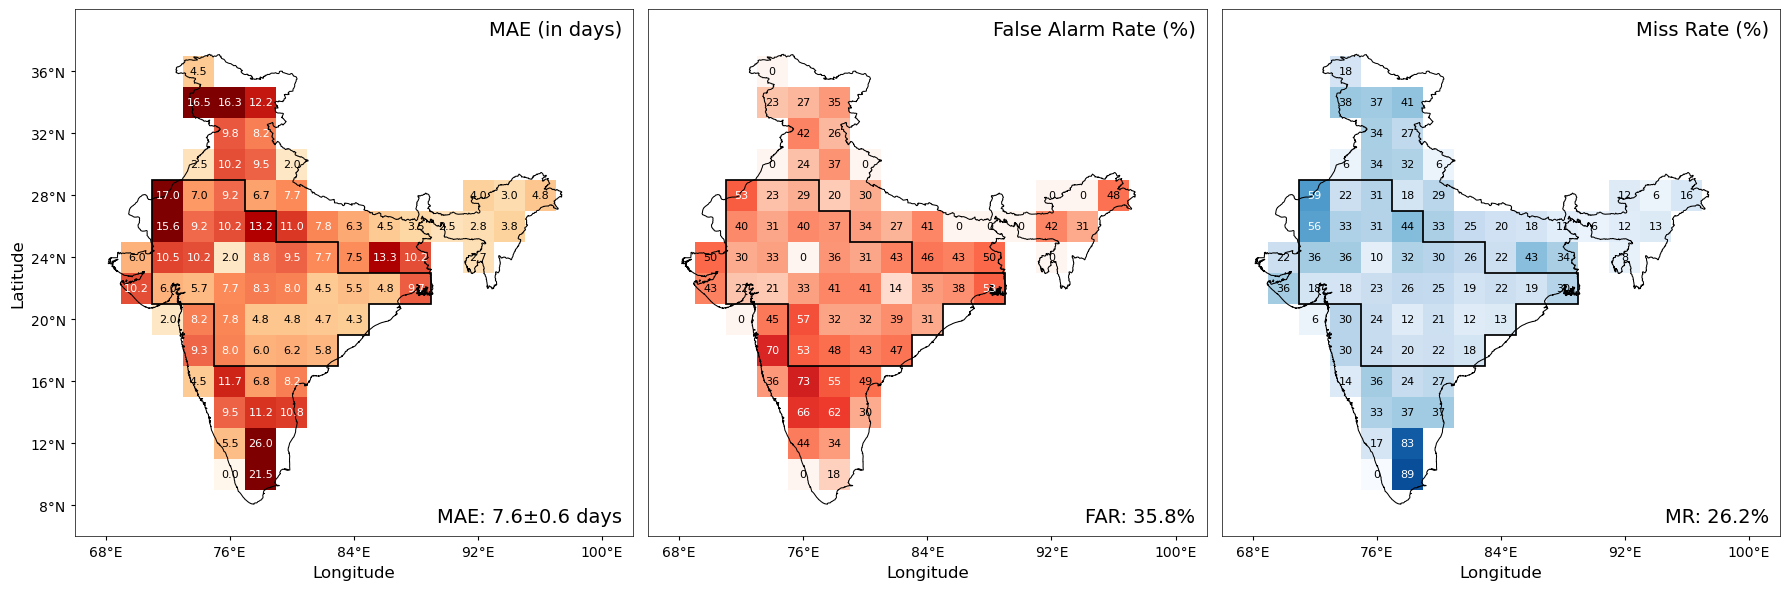


=== CORE MONSOON ZONE (CMZ) AVERAGES ===
CMZ Mean MAE (avg across years): 7.59 ± 0.62 days
CMZ False Alarm Rate: 35.8 %
CMZ Miss Rate: 26.2 %


(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: xlabel='Longitude', ylabel='Latitude'>,
        <Axes: xlabel='Longitude'>, <Axes: xlabel='Longitude'>],
       dtype=object))

In [22]:
# Example usage for 4x4 degree evaluation of AIFS model 
years = np.arange(2019, 2025)  # Add more years as needed
imd_folder = '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/2p0'
thres_file = '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_onset_threshold/mwset2x2.nc4'
shpfile_path = '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/ind_map_shpfile/india_shapefile.shp'

# Compute metrics for multiple years
metrics_df_dict, climatological_onset_doy = compute_climatology_baseline_multiple_years(
    years, imd_folder, thres_file,
    tolerance_days=5, verification_window=16, forecast_days=30,
    max_forecast_day=30, mok=True
)

spatial_metrics = create_spatial_far_mr_mae(metrics_df_dict, {year: climatological_onset_doy for year in years})

plot_spatial_metrics(spatial_metrics, figsize=(18, 6), save_path=None)

Computing climatological onset reference...
Computing climatological onset from 124 years: 1901-2024
Loading IMD rainfall from: /glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/4p0/1901.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1901-06-02) as start date for onset detection
Loading IMD rainfall from: /glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/4p0/1902.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1902-06-02) as start date for onset detection
Loading IMD rainfall from: /glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/4p0/1903.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1903-06-02) as start date for onset detection
Loading IMD rainfall from: /glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/4p0/1904.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1904-

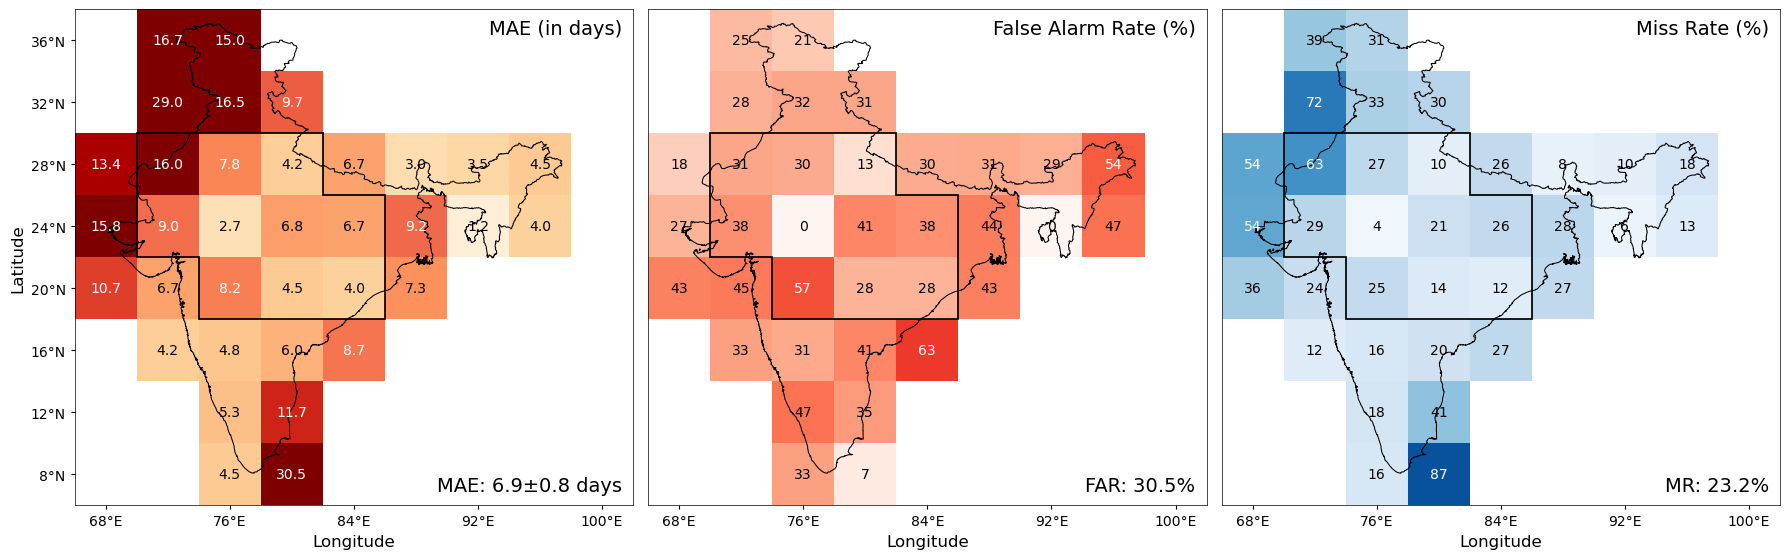


=== CORE MONSOON ZONE (CMZ) AVERAGES ===
CMZ Mean MAE (avg across years): 6.86 ± 0.76 days
CMZ False Alarm Rate: 30.5 %
CMZ Miss Rate: 23.2 %


(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: xlabel='Longitude', ylabel='Latitude'>,
        <Axes: xlabel='Longitude'>, <Axes: xlabel='Longitude'>],
       dtype=object))

In [23]:
# Example usage for 4x4 degree evaluation of AIFS model 
years = np.arange(2019, 2025)  # Add more years as needed
imd_folder = '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/4p0'
thres_file = '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_onset_threshold/mwset4x4.nc4'
shpfile_path = '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/ind_map_shpfile/india_shapefile.shp'

# Compute metrics for multiple years
metrics_df_dict, climatological_onset_doy = compute_climatology_baseline_multiple_years(
    years, imd_folder, thres_file,
    tolerance_days=5, verification_window=16, forecast_days=30,
    max_forecast_day=30, mok=True
)

spatial_metrics = create_spatial_far_mr_mae(metrics_df_dict, {year: climatological_onset_doy for year in years})

plot_spatial_metrics(spatial_metrics, figsize=(18, 6), save_path=None)

Computing climatological onset reference...
Computing climatological onset from 124 years: 1901-2024
Loading IMD rainfall from: /glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/1p0/data_1901.nc
Using MOK date (June 2nd) (1901-06-02) as start date for onset detection
Loading IMD rainfall from: /glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/1p0/data_1902.nc
Using MOK date (June 2nd) (1902-06-02) as start date for onset detection
Loading IMD rainfall from: /glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/1p0/data_1903.nc
Using MOK date (June 2nd) (1903-06-02) as start date for onset detection
Loading IMD rainfall from: /glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/1p0/data_1904.nc
Using MOK date (June 2nd) (1904-06-02) as start date for onset detection
Loading IMD rainfall from: /glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_dat

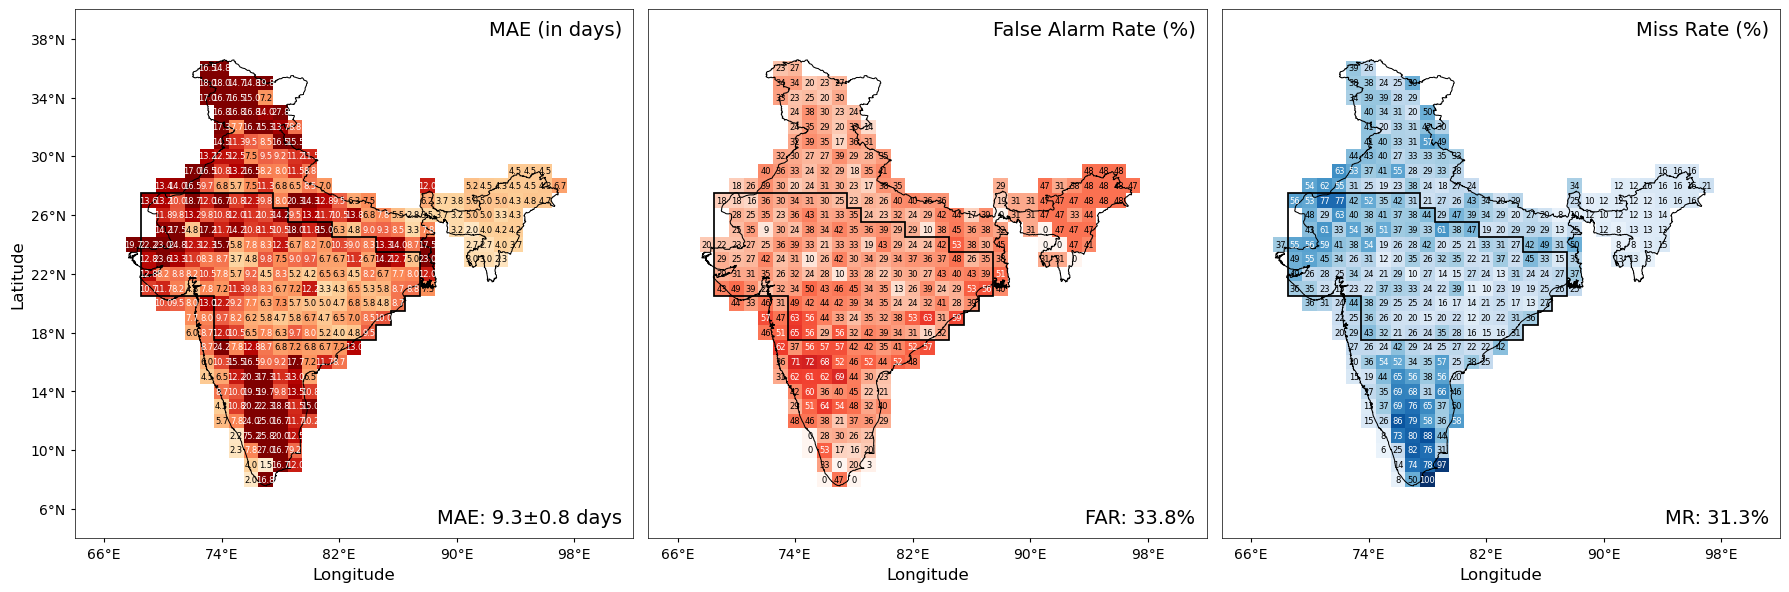


=== CORE MONSOON ZONE (CMZ) AVERAGES ===
CMZ Mean MAE (avg across years): 9.28 ± 0.79 days
CMZ False Alarm Rate: 33.8 %
CMZ Miss Rate: 31.3 %


(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: xlabel='Longitude', ylabel='Latitude'>,
        <Axes: xlabel='Longitude'>, <Axes: xlabel='Longitude'>],
       dtype=object))

In [40]:
# Example usage for 4x4 degree evaluation of AIFS model 
years = np.arange(2019, 2025)  # Add more years as needed
imd_folder = '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/1p0'
thres_file = '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_onset_threshold/mwset1x1.nc4'
shpfile_path = '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/ind_map_shpfile/india_shapefile.shp'

# Compute metrics for multiple years
metrics_df_dict, climatological_onset_doy = compute_climatology_baseline_multiple_years(
    years, imd_folder, thres_file,
    tolerance_days=5, verification_window=16, forecast_days=30,
    max_forecast_day=30, mok=True
)

spatial_metrics = create_spatial_far_mr_mae(metrics_df_dict, {year: climatological_onset_doy for year in years})

plot_spatial_metrics(spatial_metrics, figsize=(18, 6), save_path=None)